In [2]:
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Add the project root to Python path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DataLoader, create_windows_for_ml, extract_features_for_ml, FeatureConfig
from ml_toolbox.analysis.model_evaluation import evaluate_model_cv, cv_shap
from ml_toolbox.analysis import build_separability_report, cohens_d_summary

# Initialize dataset manager
dataset_path = project_root / "data_set_4"

# Load files (DataLoader supports multi-value filters)
data_loader = DataLoader(dataset_path)
data, metadata = data_loader.load_batch(
    sensor_types="vibration",
    # frequencies=20,
    # loads=0
)

# Create windows
windows, labels, win_metadata = create_windows_for_ml(
    data_list=data,
    metadata_list=metadata,
    window_size=10000,
    max_windows_per_class=10,
    random_state=42
)

# Extract features
features, feature_names = extract_features_for_ml(
    windows, 
    metadata_list=win_metadata,
    sensor_type="vibration",
)

# Evaluate model
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])
eval_res = evaluate_model_cv(pipeline, features, labels)
shap_res = cv_shap(pipeline, features, labels)

# Class separability report
# print("=== Cohen's d Class Separability ===")
# separability_summary = cohens_d_summary(features, labels, feature_names)
# separability_report = build_separability_report(separability_summary)
# separability_report.head(20)

INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers


INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'healthy': selected 10 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 10 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 10 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 10 of 4976 available windows


Evaluating model (features: (40, 50), samples: 40)...
Mean CV Accuracy: 0.675 ± 0.170
Precision: 0.662, Recall: 0.675, F1: 0.663


In [2]:
# SHAP Analysis Summary
import numpy as np

print("=== SHAP Analysis Summary ===")
num_folds = len(shap_res["shap_values_per_fold"])
print(f"Number of CV folds: {num_folds}")

# Check if multiclass or binary
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
    else:
        n_classes = first_shap.shape[2]
    print(f"Classification type: Multiclass ({n_classes} classes)")
    
    # Compute mean absolute SHAP values per feature per class across all folds
    mean_shap_per_class = []
    for class_idx in range(n_classes):
        if isinstance(first_shap, list):
            shap_vals_class = [fold["shap_values"][class_idx] for fold in shap_res["shap_values_per_fold"]]
        else:
            shap_vals_class = [fold["shap_values"][..., class_idx] for fold in shap_res["shap_values_per_fold"]]
        # Concatenate all validation samples across folds for this class
        all_shap_class = np.concatenate(shap_vals_class, axis=0)
        # Mean absolute SHAP value per feature for this class
        mean_abs_shap = np.mean(np.abs(all_shap_class), axis=0)
        mean_shap_per_class.append(mean_abs_shap)
    
    mean_shap_per_class = np.array(mean_shap_per_class)
    
else:
    print("Classification type: Binary")
    n_classes = 1
    # For binary classification, shap_values is a single array
    shap_vals = [fold["shap_values"] for fold in shap_res["shap_values_per_fold"]]
    all_shap = np.concatenate(shap_vals, axis=0)
    overall_importance = np.mean(np.abs(all_shap), axis=0)
    mean_shap_per_class = np.array([overall_importance])

# Get top 10 most important features per class
top_n = min(10, len(mean_shap_per_class[0]))

for class_idx in range(n_classes):
    print(f"\nTop {top_n} features for class {class_idx} by mean absolute SHAP value:")
    top_indices_class = np.argsort(mean_shap_per_class[class_idx])[::-1][:top_n]
    for i, idx in enumerate(top_indices_class):
        importance = mean_shap_per_class[class_idx][idx]
        feature_name = feature_names[idx]
        print(f"{i+1:2d}. {feature_name}: {importance:.4f}")

print(f"\nTotal features analyzed: {len(mean_shap_per_class[0])}")

=== SHAP Analysis Summary ===
Number of CV folds: 5
Classification type: Multiclass (4 classes)

Top 10 features for class 0 by mean absolute SHAP value:
 1. v_ch3_x_spectral_energy: 0.0243
 2. v_ch1_x_spectral_spread: 0.0228
 3. v_ch4_z_spectral_energy: 0.0202
 4. v_ch4_z_spectral_entropy: 0.0191
 5. v_ch2_z_spectral_spread: 0.0187
 6. v_ch3_x_ptp: 0.0175
 7. v_ch4_z_spectral_spread: 0.0125
 8. v_ch3_x_rms: 0.0123
 9. v_ch2_z_ptp: 0.0120
10. v_ch3_x_spectral_centroid: 0.0120

Top 10 features for class 1 by mean absolute SHAP value:
 1. v_ch1_x_form_factor: 0.0330
 2. v_ch1_x_spectral_spread: 0.0231
 3. v_ch1_x_kurtosis: 0.0215
 4. v_ch2_z_spectral_spread: 0.0182
 5. v_ch4_z_form_factor: 0.0138
 6. v_ch2_z_form_factor: 0.0131
 7. v_ch3_x_spectral_energy: 0.0129
 8. v_ch3_x_ptp: 0.0119
 9. v_ch4_z_spectral_spread: 0.0116
10. v_ch3_x_spectral_spread: 0.0111

Top 10 features for class 2 by mean absolute SHAP value:
 1. v_ch3_x_ptp: 0.0398
 2. v_ch2_z_ptp: 0.0296
 3. v_ch1_x_ptp: 0.0267
 4

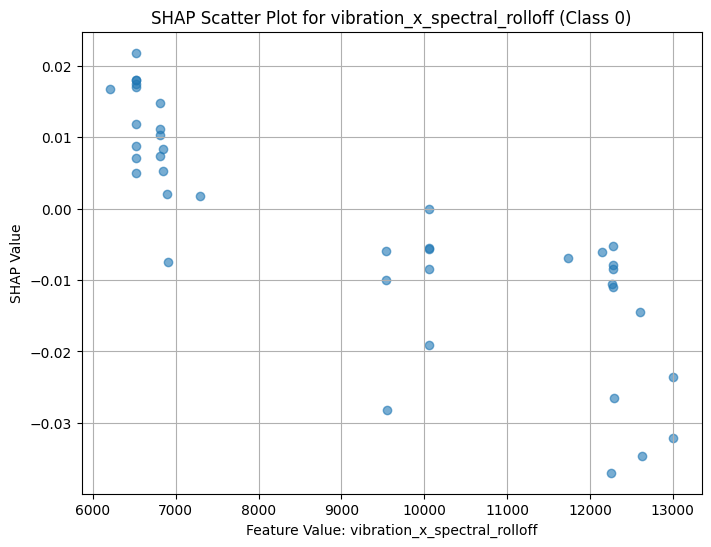

In [4]:
# SHAP Scatter Plot for Top Feature of Class 0
import matplotlib.pyplot as plt

# Get top indices for class 0
top_n = min(10, len(mean_shap_per_class[0]))
top_indices = np.argsort(mean_shap_per_class[0])[::-1][:top_n]

# Check if multiclass
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

# Get all validation SHAP values and features across folds for the top feature of class 0
if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
        all_shap_selected = np.concatenate([fold["shap_values"][0][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
    else:
        n_classes = first_shap.shape[2]
        all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0], 0] for fold in shap_res["shap_values_per_fold"]], axis=0)
else:
    all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)

all_X_selected = np.concatenate([features[fold["val_idx"], top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
feature_name_selected = feature_names[top_indices[0]]

# Plot scatter manually
plt.figure(figsize=(8, 6))
plt.scatter(x=all_X_selected, y=all_shap_selected, alpha=0.6)
plt.xlabel(f'Feature Value: {feature_name_selected}')
plt.ylabel('SHAP Value')
plt.title(f'SHAP Scatter Plot for {feature_name_selected} (Class 0)')
plt.grid(True)
plt.show()

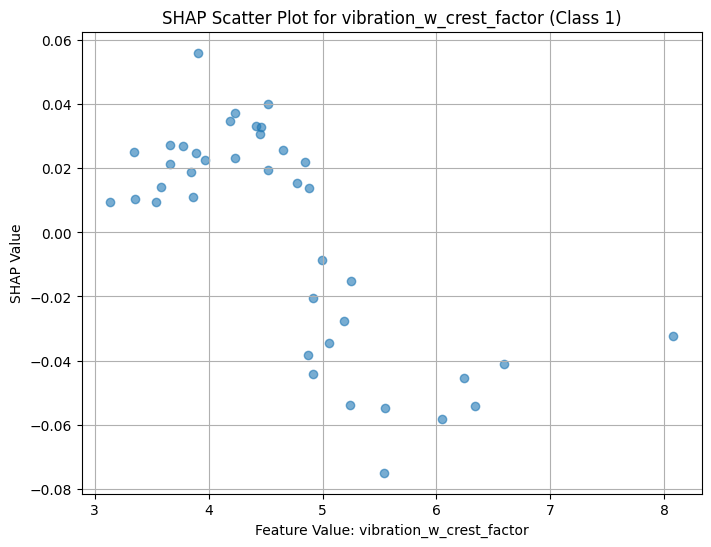

In [5]:
# SHAP Scatter Plot for Top Feature of Class 1
import matplotlib.pyplot as plt

# Get top indices for class 1
class_idx = 1
top_n = min(10, len(mean_shap_per_class[class_idx]))
top_indices = np.argsort(mean_shap_per_class[class_idx])[::-1][:top_n]

# Check if multiclass
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

# Get all validation SHAP values and features across folds for the top feature of class 1
if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
        all_shap_selected = np.concatenate([fold["shap_values"][class_idx][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
    else:
        n_classes = first_shap.shape[2]
        all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0], class_idx] for fold in shap_res["shap_values_per_fold"]], axis=0)
else:
    all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)

all_X_selected = np.concatenate([features[fold["val_idx"], top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
feature_name_selected = feature_names[top_indices[0]]

# Plot scatter manually
plt.figure(figsize=(8, 6))
plt.scatter(x=all_X_selected, y=all_shap_selected, alpha=0.6)
plt.xlabel(f'Feature Value: {feature_name_selected}')
plt.ylabel('SHAP Value')
plt.title(f'SHAP Scatter Plot for {feature_name_selected} (Class {class_idx})')
plt.grid(True)
plt.show()

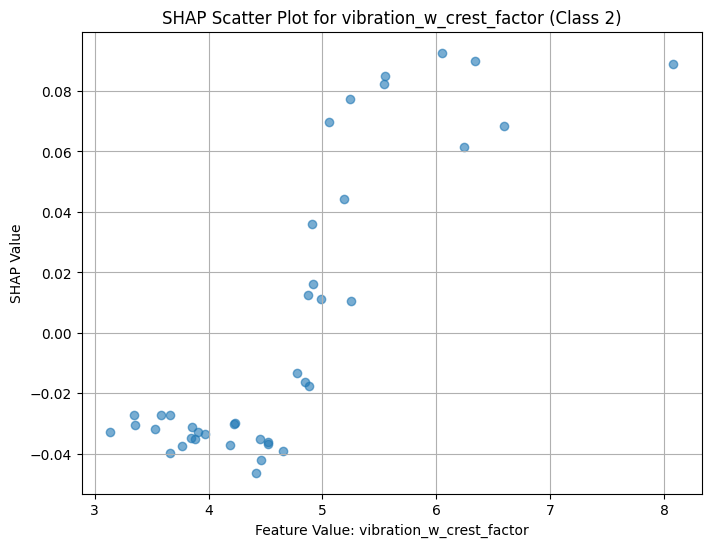

In [6]:
# SHAP Scatter Plot for Top Feature of Class 2
import matplotlib.pyplot as plt

# Get top indices for class 2
class_idx = 2
top_n = min(10, len(mean_shap_per_class[class_idx]))
top_indices = np.argsort(mean_shap_per_class[class_idx])[::-1][:top_n]

# Check if multiclass
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, 'shape') and len(first_shap.shape) == 3)

# Get all validation SHAP values and features across folds for the top feature of class 2
if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
        all_shap_selected = np.concatenate([fold["shap_values"][class_idx][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
    else:
        n_classes = first_shap.shape[2]
        all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0], class_idx] for fold in shap_res["shap_values_per_fold"]], axis=0)
else:
    all_shap_selected = np.concatenate([fold["shap_values"][:, top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)

all_X_selected = np.concatenate([features[fold["val_idx"], top_indices[0]] for fold in shap_res["shap_values_per_fold"]], axis=0)
feature_name_selected = feature_names[top_indices[0]]

# Plot scatter manually
plt.figure(figsize=(8, 6))
plt.scatter(x=all_X_selected, y=all_shap_selected, alpha=0.6)
plt.xlabel(f'Feature Value: {feature_name_selected}')
plt.ylabel('SHAP Value')
plt.title(f'SHAP Scatter Plot for {feature_name_selected} (Class {class_idx})')
plt.grid(True)
plt.show()